# User Flow Sankey Diagram

This project is based on the dataset ['The Puffy "Lost Sleep" Challenge'](https://www.kaggle.com/competitions/the-puffy-lost-sleepchallenge) hosted by [Puffy](https://puffy.com/) - an American producer of luxury mattresses and bedding.

Participants of this Kaggle competition are asked to answer the question: 'Why do some customers complete their purchase with confidence, while others hesitate or ultimately return their product?' The approach suggested by the host is to build a classification model to predict the probability that a customer will return their order.

This project, however, takes a different angle. Instead of diving into machine learning methods and building a model, it's proposed to conduct a thorough EDA (Exploratory Data Analysis).

The objective of the project is to build a User Flow Sankey Diagram specifically for customers who returned their product, to identify at which stage the return decision is made.

In [2]:
import pandas as pd
import numpy as np
import psycopg2
from sqlalchemy import create_engine, text
from tqdm.auto import tqdm
import plotly.graph_objects as go
import requests

In [3]:
pd.set_option('display.max_rows', None)

## 1. Connection to the database

For a convenience, a PostgreSQL database was set up and the tables from the dataset were imported into it. All subsequent data extraction will be done via SQL queries to this database.

In [4]:
with open('creds.txt', 'r', encoding='utf-8') as file:
    creds = file.read().splitlines()

# connect to the database
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': creds[0],  
    'user': creds[1],
    'password': creds[2]  
}

engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

# check the connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), version();"))
    db_name, version = result.fetchone()
    print(f"Connected to: {db_name}")
    print(f"PostgreSQL version: {version[:20]}...")

# print out the list of tables and counts of rows
tables_df = pd.read_sql_query("""
    SELECT 
        schemaname,
        relname as table_name,
        n_live_tup as estimated_rows
    FROM pg_stat_user_tables 
    WHERE schemaname = 'public';
""", engine)

print(tables_df)

Connected to: analytics_cjm
PostgreSQL version: PostgreSQL 17.10 on ...
  schemaname table_name  estimated_rows
0     public       tags             401
1     public     events           58119


## 2. Loading and handling data

Load events for users who returned purchases

In [5]:
%%time

df_init = pd.read_sql_query("""
    SELECT 
        events.client_id AS client_id
        ,event_name
        ,event_timestamp
        ,event_data
    FROM events
    JOIN tags
    USING(client_id)
    WHERE refunded = 1
""", engine)

CPU times: total: 78.1 ms
Wall time: 124 ms


In [6]:
df_init.sample(5)

,client_id,event_name,event_timestamp,event_data
3501,1742154076-89hyofX1veTj,page_viewed,2025-03-16 20:00:11.452,/checkouts/cn/Z2NwLXVzLXdlc3QxOjAxSlBHOEdBWk1Z...
14057,1741000534-IYc88zxz9aKd,clicked,2025-03-04 00:37:35.470,"{""element_identifier"":""layers_section""}"
2374,1742690195-MecmnNB8vTec,page_viewed,2025-03-23 00:36:39.580,/products/puffy-mattress
2408,1741548393-Kd6oQQOh7liq,page_viewed,2025-04-23 13:32:24.659,/pages/puffy-mattress-and-puffy-lux
16699,1741538805-UnxPiFyyX5hq,clicked,2025-03-09 16:52:08.155,"{""element_identifier"":""main_add_to_cart_btn""}"


Sankey diagram is a rather complex visualization. It is recommended not to include more than 50 steps into it, even for analytical research. Therefore, it is necessary to process the events and keep only the most significant ones.

The events `product_added_to_cart`, `checkout_started`, `product_removed_from_cart` and `checkout_completed` will be included in the diagram without changes. They provide the core information about the user flow within the product purchase funnel.

The event `size_changed` will be excluded, as it does not carry essential information in the context of the problem we are solving.

Understanding the rest of the user's journey (outside of actions related to adding a product to the cart and making a payment) can be formed based on the events `clicked` and/or `page_viewed`. In the context of the task under investigation, we will take a high-level view. We will track pages which users were interested in on their path to purchasing a product. So we will base our analysis on `page_viewed` events.

We will also group the pages visited by users according to their topic and role. The grouping will be based on the `event_data` attribute of events where `event_name == 'page_viewed'`.

In light of the above we will apply the foloowing event transformation.

In [7]:
# exclude 'clicked' and 'size_changed 'events
df_init = df_init[~df_init.event_name.isin(['clicked', 'size_changed'])]

# create the mask for 'page_viewed' event
mask_page_viewed = df_init.event_name == 'page_viewed'

# conditions for 'page_viewed' changing
conditions = [
    (df_init.event_data == '/'),
    ((df_init.event_data.str.startswith('/pages/puffy-mattress-and-puffy-lux')) | 
     (df_init.event_data.str.startswith('/collections')) |
     (df_init.event_data.str.startswith('/products'))),
    ((df_init.event_data.str.startswith('/pages')) & (df_init.event_data.str.contains('-vs-')) |
     (df_init.event_data == '/pages/puffy-mattress-comparison') |
     (df_init.event_data.isin(['/pages/unboxing-your-puffy-mattress', '/pages/breaking-in-your-new-puffy', 
                        '/pages/puffy-mattress-weight', '/pages/puffy-mattress-made-in-the-usa',
                        '/pages/top-rated-best-mattress-awards', 
                        '/pages/queen-mattresses', '/pages/king-mattresses',
                        '/pages/puffy-donations', '/pages/affiliates-program',
                        '/pages/easy-puffy-mattress-setup', '/pages/split-king-mattresses',
                        '/pages/certipur-us-certified'])) |
     (df_init.event_data.str.startswith('/blogs')) |
     (df_init.event_data.str.contains('reviews')) |
     (df_init.event_data == '/pages/store-locator') |
     (df_init.event_data.str.startswith('/pages/contact')) | 
     (df_init.event_data == '/pages/puffy-mattress-sleep-trial')|
     (df_init.event_data.isin(['/pages/puffy-mattress-warranty', '/pages/puffy-shipping-policy'])) |
     (df_init.event_data == '/pages/share')
    ),
    ((df_init.event_data == '/pages/financing') |
     (df_init.event_data.str.contains('discount'))),
    ((df_init.event_data == '/pages/return-policy') |
     (df_init.event_data.str.startswith('/tools/returns'))
    ),
    (df_init.event_data == '/cart'),
    (df_init.event_data.str.startswith('/checkouts')),
    (df_init.event_data.str.startswith('/apps/track-your-order'))    
]

choices = ['view_main', 
           'view_collection_product',
           'view_info',
           'view_financ_discount',
           'view_return',
           'view_cart',
           'view_ckeckout',
           'view_track'
          ]

df_init.loc[mask_page_viewed, 'event_name'] = np.select(
    [cond[mask_page_viewed] for cond in conditions],
    choices,
    default=df_init.loc[mask_page_viewed, 'event_name']
)

In [8]:
df_init.sample(5)

,client_id,event_name,event_timestamp,event_data
4394,1742067604-wn9FxSqfNG6m,view_collection_product,2025-03-15 19:49:52.231,/products/puffy-royal-mattress
3436,1741555003-3wxw6PUPsTPB,view_financ_discount,2025-03-09 21:18:47.236,/pages/teachers-students-discount
6178,1741603254-sdQAwfUOhHEt,view_collection_product,2025-03-10 10:43:47.304,/products/puffy-monarch-mattress
5955,1742663235-PYeeY1saAFYL,view_ckeckout,2025-03-22 19:54:13.150,/checkouts/cn/Z2NwLXVzLWVhc3QxOjAxSlBaREJTMVdY...
4156,1741000534-IYc88zxz9aKd,view_collection_product,2025-03-23 12:25:53.206,/products/puffy-topper


In [9]:
# check if we didn't miss any page_view event
df_init[df_init.event_name == 'page_viewed']

,client_id,event_name,event_timestamp,event_data


The aim of the further refinement of the dataset is to reduce the number of steps displayed in the user flow map. We need to keep the most significant steps. At the same time we shouldn't miss any trigger that may influence the user's decision to make a return.

If users purchased a product, they must have previously viewed its details and visited the cart. That is why `view_main`, `view_collection_product`, and `view_cart` events aren't significant. The `view_ckeckout` event also may be skipped, as `checkout_started` event is more informative

In [10]:
df_init = df_init[~df_init.event_name.isin(['view_main', 'view_collection_product', 
                                            'view_ckeckout', 'view_cart'])]

Users may reload the same page multiple times or navigate to similar pages (for example, viewing different product or collection cards). These actions are essentially similar from the perspective of the task under consideration. That's why we apply additional processing:
- we sort the dataframe by client_id and event_timestamp;
- we keep only the first occurrence for consecutive duplicate event_name entries.

At the same time, we'll preserve the original dataframe as `df_init`, since we might need it later to get additional information. The processed dataframe is saved as a new one `df`

In [11]:
df_sorted = df_init.sort_values(['client_id', 'event_timestamp'])

df = df_sorted[
    df_sorted.groupby('client_id')['event_name'].transform(
        lambda x: x != x.shift()
    )
]

One more preprocessing step to generalize user behavior: we'll drop sequences consisting of consecutive `product_added_to_cart` and `product_removed_from_cart` actions

In [12]:
df = df.sort_values(['client_id', 'event_timestamp'])

indices_to_drop = []

for client_id in df['client_id'].unique():
    client_mask = df['client_id'] == client_id
    client_df = df[client_mask].sort_values('event_timestamp')
    
    i = 0
    while i < len(client_df):
        if client_df.iloc[i]['event_name'] == 'product_added_to_cart':
            for j in range(i + 1, len(client_df)):
                if client_df.iloc[j]['event_name'] == 'product_removed_from_cart':
                    # Append indexes of rows from i to j
                    indices_to_drop.extend(client_df.index[i:j+1].tolist())
                    i = j
                    break
            else:
                i += 1
        else:
            i += 1

df = df.drop(index=set(indices_to_drop))

## 3. Creating User Flow Map

We will visualize user flow with sankey diagram. The article https://habr.com/ru/articles/566568/ (in Russian) provides a comprehensive guide on how to build a Sankey diagram.

Let's define a function that identifies "source-target" pairs for a dataframe and also numerates the steps for these pairs based on the event occurrence time

In [13]:
def add_features(df):

    """Generates new columns for the initial dataframe

    Args:
        df (pd.DataFrame): initial dataframe.
    Returns:
        pd.DataFrame: dataframe with new features.
    """

    # sort the dataframe by client_id and timestamp of event
    sorted_df = df.sort_values(by=['client_id', 'event_timestamp']).copy()
    # add step feature
    sorted_df['step'] = sorted_df.groupby('client_id').cumcount() + 1

    # define source and target nodes 
    # source nodes are events
    sorted_df['source'] = sorted_df['event_name']
    # target nodes are events, that follow source events
    sorted_df['target'] = sorted_df.groupby('client_id')['source'].shift(-1)

    # return the handled dataframe
    return sorted_df

In [14]:
df = add_features(df)

df.head()

,client_id,event_name,event_timestamp,event_data,step,source,target
5052,1736925415-sVhNOcrr39sh,view_info,2025-01-16 03:39:50.828,/pages/share,1,view_info,product_added_to_cart
6266,1736925415-sVhNOcrr39sh,product_added_to_cart,2025-03-02 05:46:26.806,7312761618466,2,product_added_to_cart,checkout_started
523,1736925415-sVhNOcrr39sh,checkout_started,2025-03-02 05:46:59.875,7420505194530,3,checkout_started,product_added_to_cart
397,1736925415-sVhNOcrr39sh,product_added_to_cart,2025-03-06 21:06:45.722,7124195180578,4,product_added_to_cart,checkout_started
4421,1736925415-sVhNOcrr39sh,checkout_started,2025-03-16 04:12:05.323,7420501327906,5,checkout_started,checkout_completed


To better understand how deep the user flow map will be, let's examine the distribution of the maximum step count for users who made purchases and returned them

<Axes: >

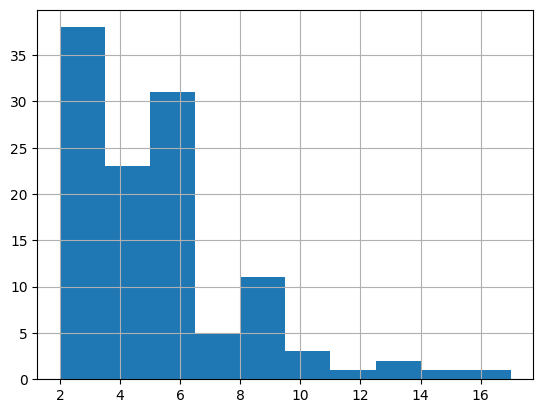

In [15]:
steps = df.groupby('client_id')['step'].agg('max')
        
steps.hist(bins=10)

As seen from the histogram, the user flow map will be fairly easy to interpret: maximum depth is 17 steps, but the majority of users follow paths of 6 steps or less.

Next, we enumerate all events in the queue by grouping first by step, then by event name within the step, and assigning sequential index to each event

In [16]:
def get_source_index(df):

    """Function to generate indices for source-nodes

    Args:
        df (pd.DataFrame): initial dataframe with step, source and target features.
    Returns:
        dict: dictionary with correspondence of indices to source names.
    """

    res_dict = {}

    count = 0
    # get the indices for sources 
    for no, step in enumerate(df['step'].unique().tolist()):
        # get unique sources' names for every step
        res_dict[no+1] = {}
        res_dict[no+1]['sources'] = df[df['step'] == step]['source'].unique().tolist()
        res_dict[no+1]['sources_index'] = []
        for i in range(len(res_dict[no+1]['sources'])):
            res_dict[no+1]['sources_index'].append(count)
            count += 1

    # zip lists
    for key in res_dict:
        res_dict[key]['sources_dict'] = {}
        for name, no in zip(res_dict[key]['sources'], res_dict[key]['sources_index']):
            res_dict[key]['sources_dict'][name] = no
    return res_dict

In [17]:
source_indexes = get_source_index(df)

We associate each event name with a color. The next function can generate random colors or use a custom palette.

In [18]:
def colors_for_sources(df, mode):

    """Generate colors rgba

    Returns:
        dict: dictionary with event names and colors
    """
    
    colors_dict = {}
    
    if mode == 'random':
        # generate random colors
        for label in df_comp['source'].unique():
            r, g, b = np.random.randint(255, size=3)            
            colors_dict[label] = f'rgba({r}, {g}, {b}, 1)'
            
    elif mode == 'custom':
        # take custom colors
        colors = requests.get('https://raw.githubusercontent.com/ElenaNKn/data_projects/refs/heads/master/project_sankey/colors_senkey.json').json()
        for no, label in enumerate(df['source'].unique()):
            colors_dict[label] = colors['custom_colors'][no]
            
    return colors_dict

In [19]:
colors_dict = colors_for_sources(df, 'custom')
colors_dict

{'view_info': 'rgba(255, 165, 0, 1)',
 'product_added_to_cart': 'rgba(81, 170, 86, 1)',
 'checkout_started': 'rgba(29, 160, 189, 1)',
 'checkout_completed': 'rgba(29, 48, 243, 1)',
 'product_removed_from_cart': 'rgba(238, 130, 238, 1)',
 'view_track': 'rgba(230, 57, 70, 1)',
 'view_return': 'rgba(255, 0, 0, 1)',
 'view_financ_discount': 'rgba(255, 217, 2, 1)'}

In [20]:
# calculate user share as percentage of users on the source node
def percent_users(sources, targets, values):

    """
    Calculation of customers share as a percentage of users, who entered the node 
    (to be shown as hover text for each source)

    Args:
        sources (list): list with source indices.
        targets (list): list with target indices.
        values (list): list with volumes of flows.

    Returns:
        list: list with users' shares
    """

    zip_lists = list(zip(sources, targets, values))

    new_list = []

    # dictionary with traffic volume for every node
    unique_dict = {}

    # iterate by nodes
    for source, target, value in zip_lists:
        if source not in unique_dict:
            # find all sources and calculate the total traffic
            unique_dict[source] = 0
            for sr, tg, vl in zip_lists:
                if sr == source:
                    unique_dict[source] += vl

    # calculate percentages
    for source, target, value in zip_lists:
        new_list.append(round(100 * value / unique_dict[source], 1))

    return new_list

Now we will create lists, that will be input data for the Sankey diagram

In [21]:
def lists_for_plot(df_comp, source_indexes, colors=colors_dict, frac=0):

    """
    Create lists to plot sankey diagram

    Args:
        source_indexes (dict): dictionary with names and indices of source nodes.
        colors (dict): dictionary with colors for source.
        frac (int): mininal allowable traffic between nodes.

    Returns:
        dict: dictionary with lists for the Sankey diagram.
    """

    sources = []
    targets = []
    values = []
    labels = []
    link_color = []
    link_text = []

    # iterate bu steps
    for step in tqdm(sorted(df_comp['step'].unique()), desc='Шаг'):
        if step + 1 not in source_indexes:
            continue

        # get indices of the source nodes
        temp_dict_source = source_indexes[step]['sources_dict']

        # get indices of the target nodes
        temp_dict_target = source_indexes[step+1]['sources_dict']

        # iterate by every possible pare and calculate the count of such pairs
        for source, index_source in tqdm(temp_dict_source.items()):
            for target, index_target in temp_dict_target.items():
                temp_df = df_comp[(df_comp['step'] == step)&(df_comp['source'] == source)&(df_comp['target'] == target)]
                value = len(temp_df)
                # check for minimal allowable traffic
                if value > frac:
                    sources.append(index_source)
                    targets.append(index_target)
                    values.append(value)
                    link_color.append(colors[source].replace(', 1)', ', 0.2)'))

    labels = []
    colors_labels = []
    for key in source_indexes:
        for name in source_indexes[key]['sources']:
            labels.append(name)
            colors_labels.append(colors[name])

    # convert to percentage
    perc_values = percent_users(sources, targets, values)

    link_text = []
    for perc in perc_values:
        link_text.append(f"{perc}%")

    return {'sources': sources,
            'targets': targets,
            'values': values,
            'labels': labels,
            'colors_labels': colors_labels,
            'link_color': link_color,
            'link_text': link_text}

In [22]:
data_for_plot = lists_for_plot(df, source_indexes)

100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 227.10it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 239.77it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 280.09it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 333.44it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 277.74it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 285.75it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 312.52it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 363.43it/s]

100%|███████████████████████████

In [23]:
def plot_senkey_diagram(data_dict):

    """
    Function to generate sankey diagram object 

    Args:
        data_dict (dict): dictionary with all preliminary prepared data.

    Returns:
        plotly.graph_objs._figure.Figure: sankey diagram object.
    """

    fig = go.Figure(data=[go.Sankey(
        domain = dict(
          x =  [0,1],
          y =  [0,1]
        ),
        orientation = "h",
        valueformat = ".0f",
        node = dict(
          pad = 50,
          thickness = 15,
          line = dict(color = "black", width = 0.1),
          label = data_dict['labels'],
          color = data_dict['colors_labels']
        ),
        link = dict(
          source = data_dict['sources'], # indices correspond to labels, eg A1, A2, A1, B1, ...
          target = data_dict['targets'],
          value = data_dict['values'],
          label = data_dict['link_text'],
          color = data_dict['link_color']
      ))])
    fig.update_layout(title_text="User Flow: Returned Product Users", font_size=10, width=3000, height=1200)

    return fig

Next we'll plot sankey diagram to visualize user flow map for for users who made purchases and returned them.

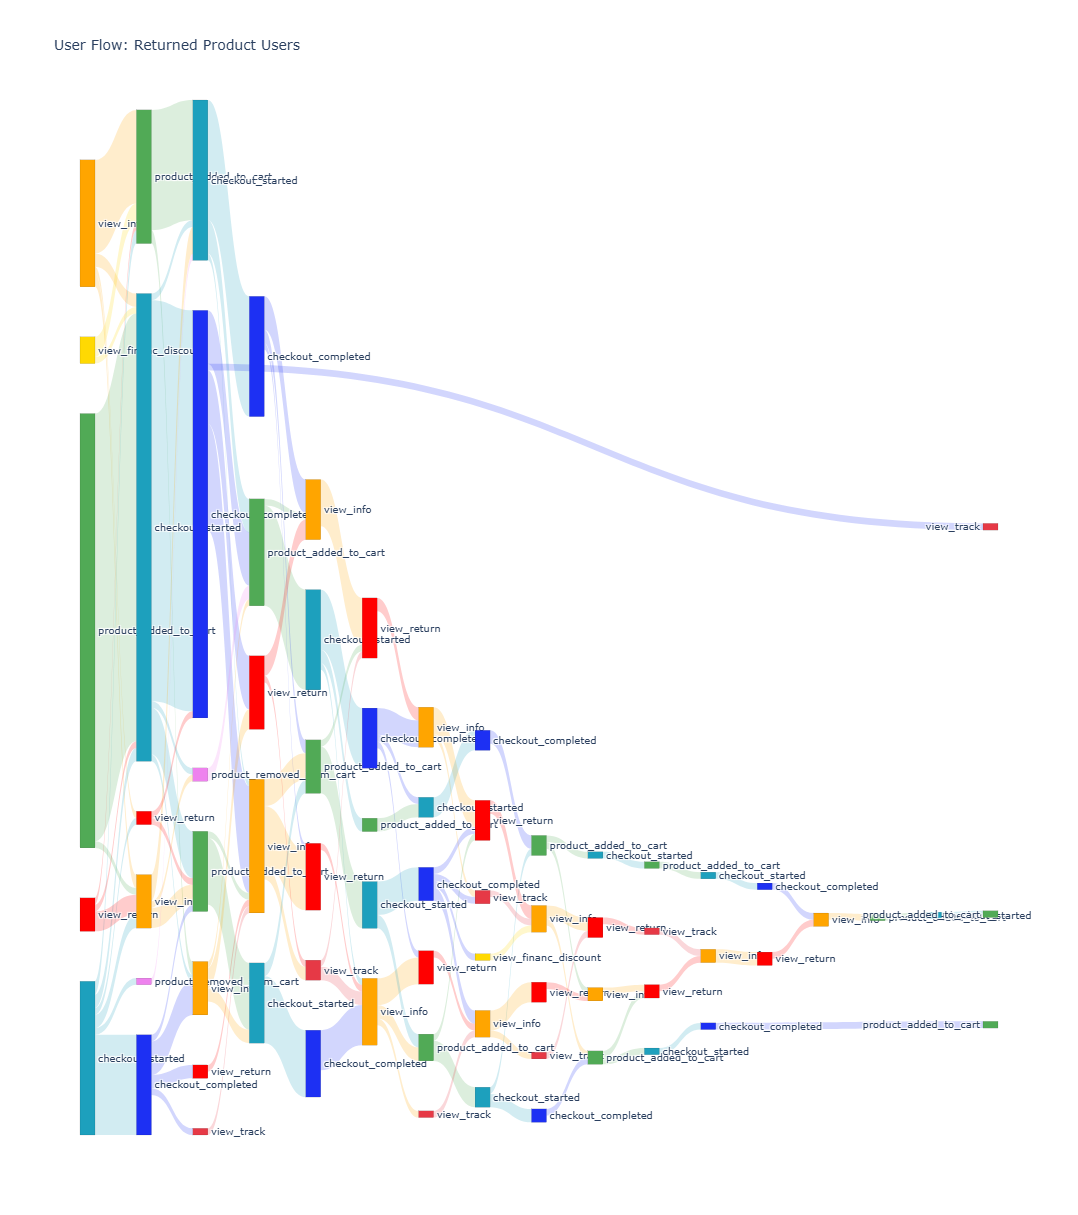

In [24]:
senkey_diagram = plot_senkey_diagram(data_for_plot)
senkey_diagram.show()

We'll store the Sankey diagram as html-file

In [25]:
senkey_diagram.write_html('UserFlow_returned_product.html')

From the visualization obtained, the following can be observed:

1. The data provided in the dataset are incomplete. Some users' journeys don't start with adding an item to the cart but jump straight to checkout.
2. There are users who view the return policy at the very beginning of their journey.
3. The majority of other product returns occurred after users had viewed informational materials on the site.

Let's take a closer look at points 2 and 3.

In [26]:
# count of customers who returned purchases
clients_with_return = df.client_id.nunique()
clients_with_return

116

In [27]:
# count and share of users, whose user flow started with the return policy or other return pages
cust_initial_return_count = df[(df.step == 1) & (df.event_name == 'view_return')].client_id.nunique()
cust_initial_return_share = round(100 * cust_initial_return_count / df.client_id.nunique(), 2)

print(f'Users, whose user flow started with the return pages:\n')
print(f'User count: {cust_initial_return_count}')
print(f'User share (of all users, who returned purchases): {cust_initial_return_share}%')

Users, whose user flow started with the return pages:

User count: 5
User share (of all users, who returned purchases): 4.31%


Thus, there are users who think about how to return the purchase at the very start of user flow. This may indicate that they hesitated about purchasing the product. But it's not a mass phenomenon. However, it makes sense to track such users (those who visited the return policy page before adding the product to the cart) and offer them:
- an additional modal window clarifying their willingness to proceed with the order;
- personalized post-purchase communication aimed at return prevention.

Now let's determine the share of users who viewed informational materials on the site after placing an order but before navigating to pages related to product returns.

In [28]:
def check_sequence_efficient(group):
    """
    Function to check if user action has the sequence of events
        'checkout_completed -> view_info -> view_return'

    Args:
        group: user events.

    Returns:
        bool: True , if user has visited info pages after placing an order but before navigating 
            to pages related to product returns
    """
    checkout_times = group[group['event_name'] == 'checkout_completed']['event_timestamp'].values
    view_info_times = group[group['event_name'] == 'view_info']['event_timestamp'].values
    view_return_times = group[group['event_name'] == 'view_return']['event_timestamp'].values
    
    for checkout_time in checkout_times:
        valid_view_info = view_info_times[view_info_times > checkout_time]
        for view_info_time in valid_view_info:
            if any(view_return_time > view_info_time for view_return_time in view_return_times):
                return True
    return False

In [29]:
# share of users who viewed informational materials on the site after placing an order 
# but before navigating to pages related to product returns

cust_info_return_count = df.groupby('client_id').filter(check_sequence_efficient)['client_id'].nunique()
cust_info_return_share = round(100 * cust_info_return_count / df.client_id.nunique(), 2)

print(f'Users who viewed informational materials on the site after placing an order\n'+
      f'but before navigating to pages related to product returns\n')
print(f'User count: {cust_info_return_count}')
print(f'User share (of all users, who returned purchases): {cust_info_return_share}%')

Users who viewed informational materials on the site after placing an order
but before navigating to pages related to product returns

User count: 30
User share (of all users, who returned purchases): 25.86%


Thus, a quarter of users who returned a product had previously viewed informational materials on the site.

To better understand their behavior, we now examine which specific pages these users viewed before initiating the return. Using the raw DataFrame `df_init`, we extract all `view_info` events that occurred between the `checkout_completed` and `view_return` events for this subset of users.

In [30]:
target_clients = df_init.groupby('client_id').filter(check_sequence_efficient)['client_id'].unique()

result = []

# iterate over target customers, save time of checkout_completed and view_return
# investigate view_info events, which are in between checkout_completed and view_return
for client_id in target_clients:
    client_df = df_init[df_init['client_id'] == client_id].sort_values('event_timestamp')
    
    checkout_ts_list = client_df[client_df['event_name'] == 'checkout_completed']['event_timestamp'].tolist()
    return_ts_list = client_df[client_df['event_name'] == 'view_return']['event_timestamp'].tolist()
    
    view_info_df = client_df[client_df['event_name'] == 'view_info']
    
    for idx, row in view_info_df.iterrows():
        view_ts = row['event_timestamp']
        has_before = any(ts < view_ts for ts in checkout_ts_list)
        has_after = any(ts > view_ts for ts in return_ts_list)
        if has_before and has_after:
            result.append(row)

info_df = pd.DataFrame(result)

In [31]:
info_df.head()

,client_id,event_name,event_timestamp,event_data
3193,1741313717-XoA7tCkAvrQ-,view_info,2025-03-08 22:14:26.357,/pages/puffy-mattress-reviews
820,1741313717-XoA7tCkAvrQ-,view_info,2025-03-08 22:14:36.418,/pages/puffy-lux-mattress-reviews
3263,1741313717-XoA7tCkAvrQ-,view_info,2025-03-26 17:25:49.668,/pages/puffy-mattress-reviews
28,1741313717-XoA7tCkAvrQ-,view_info,2025-03-26 17:30:17.241,/pages/puffy-mattress-reviews
3295,1741724699-Fk1TvqbjmPmc,view_info,2025-03-20 14:43:17.700,/pages/contact-puffy-mattress


In [32]:
result_info_views = info_df.groupby('event_data').agg(
    clients = ('client_id', 'nunique'),
    view_counts = ('event_name', 'count')
).sort_values(by = 'clients', ascending = False).head(10)

result_info_views['views_per_client'] = round(result_info_views['view_counts'] / result_info_views['clients'], 2)
result_info_views

,clients,view_counts,views_per_client
event_data,,,
/pages/contact-puffy-mattress,23,45,1.96
/pages/puffy-mattress-sleep-trial,8,15,1.88
/pages/puffy-mattress-reviews,4,7,1.75
/pages/breaking-in-your-new-puffy,3,4,1.33
/blogs/best-sleep/king-vs-queen-bed-detailed-mattress-size-comparison,2,2,1.00
/pages/share,2,3,1.50
/pages/unboxing-your-puffy-mattress,2,2,1.00
/pages/store-locator,2,2,1.00
/pages/puffy-donations,2,7,3.50


In [33]:
# total count of clients who were interested in the warranty or reviews
clients_warenty_reviews = info_df[info_df.event_data.isin(['/pages/puffy-mattress-sleep-trial', 
                                 '/pages/puffy-mattress-reviews'])].client_id.nunique()
clients_warenty_reviews_share = round(100 * clients_warenty_reviews / df.client_id.nunique(), 2)

print(f'Users who viewed waranty and reviews after placing an order\n'+
      f'but before navigating to pages related to product returns\n')
print(f'User count: {clients_warenty_reviews}')
print(f'User share (of all users, who returned purchases): {clients_warenty_reviews_share}%')

Users who viewed waranty and reviews after placing an order
but before navigating to pages related to product returns

User count: 11
User share (of all users, who returned purchases): 9.48%


The results show that 30 clients viewed informational pages after placing an order but before initiating a return. Of these:

- 23 clients (19.8% of all returners) viewed contact information. A deeper analysis of this group would require data from the customer service department;
- 8 clients (7.9% of returners) were interested in the warranty and the mattress trial-period option;
- 4 clients (3.4% of returners) viewed mattress reviews.

There is no concrete information about the reasons, why 116 clients returned their purchases. We may consider that 11 clients, who were interested in the warranty, mattress trial-period option and reviews (9.48% off all clients, who returned product) were not suttisfied with mattresses characteristics. But only 3 clients visited the page `/pages/breaking-in-your-new-puffy`. This page explains that mattress break-in and adaptation take about 30 days.

## 4. Conclusions

Analysis of the user flow map revealed the following:

- 4.31% of users who ordered and later returned a product had visited the return policy page before making their purchase. It's suggested to track these users (those who viewed the return policy before adding the item to the cart) and either show them an extra modal that confirms their intent to buy, or reach them out with personalized post-purchase messaging aimed at reducing the likelihood of a return.
- 25.86% of users with returned products viewed informational content on the site between placing their order and initiating a return. A closer look at what they viewed shows that most checked the store's contact page (further investigation here would require data from the customer support team).
- 9.48% of users with returned products viewed information about the warranty, trial-period and reviews. It can be suggested that they weren't fully satisfied with their choice. However, only 3 customers (2.6% of all returns) visited the page that explains that the mattress needs about 30 days to break in and adapt to the user.

Overall, these findings point to a need to rethink how the information on the site is currently presented and how effective communication with users is. It should be more clear and visual shown that the mattress requires an adjustment period. Right now, it seems that many users are returning the product without ever having seen that specific information.